In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import holidays

In [144]:
data = pd.read_csv('data.csv')
print(data.head())

  shipped_date     sku channel  qty   revenue  cost of good sold  MOQ order
0     1/1/2021  089A0E     ADS  190   5027.40            2926.00      56460
1     1/1/2021  089A0E     AWH   30    793.80                NaN      56460
2     1/1/2021  0FKFLA     AWH  780  32028.36           13104.00     427545
3     1/1/2021  0G8Z4M     AWH   85   1307.81             595.00       2516
4     1/1/2021  0NFJ14     FBM   38   2127.47            1723.25      18734


In [145]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48363 entries, 0 to 48362
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   shipped_date       48363 non-null  str    
 1   sku                48363 non-null  str    
 2   channel            48363 non-null  str    
 3   qty                48363 non-null  int64  
 4   revenue            44099 non-null  float64
 5   cost of good sold  43311 non-null  float64
 6   MOQ order          48363 non-null  int64  
dtypes: float64(2), int64(2), str(3)
memory usage: 2.6 MB


In [146]:
data.rename(columns={'cost of good sold': 'COGS','MOQ order':'MOQ_orders'}, inplace=True)

In [147]:
print(data['sku'].nunique())
print(data['shipped_date'].min())
print(data['shipped_date'].max())

676
1/1/2021
9/8/2021


In [150]:
data.head(3)

,shipped_date,sku,channel,qty,revenue,COGS,MOQ_orders
0,1/1/2021,089A0E,ADS,190,5027.40,2926.0,56460
1,1/1/2021,089A0E,AWH,30,793.80,NaN,56460
2,1/1/2021,0FKFLA,AWH,780,32028.36,13104.0,427545


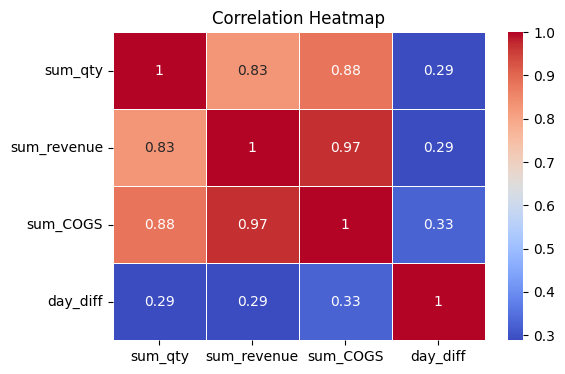

In [156]:
data['shipped_date'] = pd.to_datetime(data['shipped_date'])
data_group = data.groupby('sku').agg({'shipped_date': ['min', 'max'],
                                      'qty': 'sum',
                                      'revenue':'sum',
                                      'COGS':'sum'})


data_group.columns = ['min_date', 'max_date', 'sum_qty', 'sum_revenue', 'sum_COGS']
data_group['day_diff'] = (data_group['max_date'] - data_group['min_date']).dt.days
data_group = data_group.reset_index()
data_corr = data_group.corr(numeric_only=True)
plt.figure(figsize=(6, 4))
sns.heatmap(data_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [157]:
data_group.head(3)

,sku,min_date,max_date,sum_qty,sum_revenue,sum_COGS,day_diff
0,017SAD,2021-01-03,2021-09-24,1425,56849.10,32604.74,264
1,07GH,2021-01-05,2021-03-30,468,16380.00,13267.80,84
2,085DAS,2021-11-11,2021-12-17,225,9131.85,5673.15,36


In [33]:
data_group.sort_values(by='sum_revenue', ascending=False)

,sku,min_date,max_date,sum_qty,sum_revenue,sum_COGS,day_diff
284,FJDJ6B,2021-01-01,2022-01-02,1135864,32805797.82,16436591.08,366
592,VJK56C,2021-01-01,2022-01-02,235914,31612867.38,11922944.32,366
124,67LPLP,2021-01-01,2022-01-02,445832,15605137.44,12017534.41,366
129,6HSD4J,2021-01-01,2022-01-02,188699,8971421.55,5600106.36,366
157,7XL27C,2021-01-01,2022-01-02,61438,7347716.60,3224046.06,366
...,...,...,...,...,...,...,...
8,0LQHLA,2021-08-15,2021-08-15,76,0.00,0.00,0
579,V0NLGV,2021-03-12,2021-03-12,89,0.00,0.00,0
218,B4DZY9,2021-10-30,2021-10-30,85,0.00,0.00,0
454,NJEWPV,2021-05-27,2021-05-27,16,0.00,0.00,0


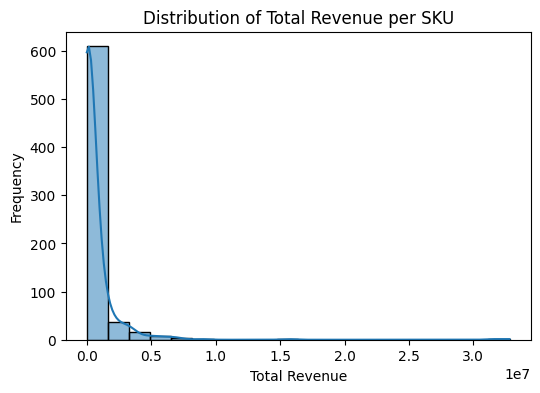

In [34]:
plt.figure(figsize=(6, 4))
sns.histplot(data_group['sum_revenue'], bins=20, kde=True)
plt.title('Distribution of Total Revenue per SKU')
plt.xlabel('Total Revenue')
plt.ylabel('Frequency')
plt.show()

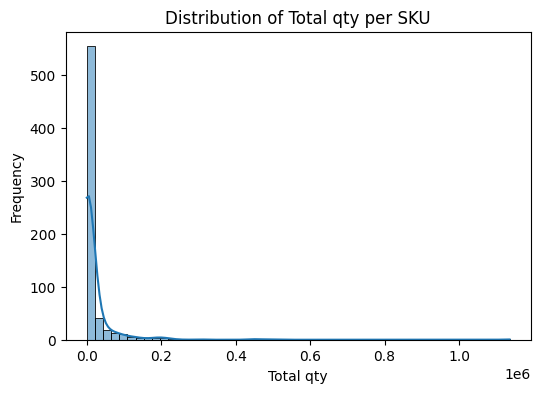

In [48]:
plt.figure(figsize=(6, 4))
sns.histplot(data_group['sum_qty'],kde=True)
plt.title('Distribution of Total qty per SKU')
plt.xlabel('Total qty')
plt.ylabel('Frequency')
plt.show()

In [49]:
data_group['sum_qty'].describe()

count    6.630000e+02
mean     1.898595e+04
std      6.418627e+04
min      6.000000e+00
25%      1.500000e+02
50%      1.728000e+03
75%      1.024600e+04
max      1.135864e+06
Name: sum_qty, dtype: float64

In [40]:
data_group = data_group[~data_group.index.isin(data_group.loc[(data_group['sum_revenue']==0)&(data_group['sum_qty']>0)].index)]
#remove all these sku from the data
print(data_group.shape)

(663, 7)


In [52]:
data_group.sort_values(by='sum_revenue', ascending=False).head(10)

,sku,min_date,max_date,sum_qty,sum_revenue,sum_COGS,day_diff
284,FJDJ6B,2021-01-01,2022-01-02,1135864,32805797.82,16436591.08,366
592,VJK56C,2021-01-01,2022-01-02,235914,31612867.38,11922944.32,366
124,67LPLP,2021-01-01,2022-01-02,445832,15605137.44,12017534.41,366
129,6HSD4J,2021-01-01,2022-01-02,188699,8971421.55,5600106.36,366
157,7XL27C,2021-01-01,2022-01-02,61438,7347716.60,3224046.06,366
405,LHR5LZ,2021-01-01,2021-12-31,172704,6884552.78,2047874.42,364
99,4OCITK,2021-01-01,2022-01-02,454305,6846770.61,4231463.30,366
24,1JKADT,2021-01-01,2022-01-02,489020,6513120.15,4715442.37,366
335,HK1R6J,2021-01-01,2022-01-02,31878,6215607.48,3886929.17,366
647,Y6HWKQ,2021-01-01,2022-01-02,205000,6018820.21,4048458.74,366


In [42]:
data_group[data_group['day_diff']==366]['sku'].nunique()

128

#### choose top 10 SKU that contribute most to revenue to forecast: 

In [161]:
top_10_sku = data_group.sort_values(by='sum_revenue', ascending=False).head(10)['sku'].tolist()
print(top_10_sku)

['FJDJ6B', 'VJK56C', '67LPLP', '6HSD4J', '7XL27C', 'LHR5LZ', '4OCITK', '1JKADT', 'HK1R6J', 'Y6HWKQ']


In [162]:
data_group_sku = data.groupby(['shipped_date', 'sku']).agg({'qty': 'sum', 'revenue':'sum', 'COGS':'sum'}).reset_index()
data_forecast = data_group_sku[data_group_sku['sku'].isin(top_10_sku)]
print(data_forecast.shape)
data_forecast.head()

(1778, 5)


,shipped_date,sku,qty,revenue,COGS
9,2021-01-01,1JKADT,3038,46742.67,33627.72
36,2021-01-01,4OCITK,3472,58280.99,34025.60
45,2021-01-01,67LPLP,2576,100943.14,72128.00
47,2021-01-01,6HSD4J,1078,52806.91,33806.08
54,2021-01-01,7XL27C,306,55490.65,17564.40


In [163]:
date_template = pd.DataFrame({'shipped_date': pd.date_range(start=data_forecast['shipped_date'].min(), end=data_forecast['shipped_date'].max())})
date_template['key'] = 1
sku_template = pd.DataFrame({'sku': top_10_sku})
sku_template['key'] = 1
template = pd.merge(date_template, sku_template, on='key').drop('key', axis=1)
data_forecast = pd.merge(template, data_forecast, on=['shipped_date', 'sku'], how='left')
data_forecast['qty'] = data_forecast['qty'].fillna(0)
data_forecast['revenue'] = data_forecast['revenue'].fillna(0)
data_forecast['COGS'] = data_forecast['COGS'].fillna(0)
print(data_forecast.head())

  shipped_date     sku     qty    revenue      COGS
0   2021-01-01  FJDJ6B  5822.0  162934.49  89036.58
1   2021-01-01  VJK56C   984.0  206626.22  52348.80
2   2021-01-01  67LPLP  2576.0  100943.14  72128.00
3   2021-01-01  6HSD4J  1078.0   52806.91  33806.08
4   2021-01-01  7XL27C   306.0   55490.65  17564.40


#### feature engineering: 

In [164]:
data_forecast['month'] = data_forecast['shipped_date'].dt.month
data_forecast['day'] = data_forecast['shipped_date'].dt.day
data_forecast['dayofweek'] = data_forecast['shipped_date'].dt.dayofweek
data_forecast['weekofyear'] = data_forecast['shipped_date'].dt.isocalendar().week

data_forecast['is_even_day'] = (data_forecast['day'] % 2 == 0).astype(int)
print(data_forecast.head())

  shipped_date     sku     qty    revenue      COGS  month  day  dayofweek  \
0   2021-01-01  FJDJ6B  5822.0  162934.49  89036.58      1    1          4   
1   2021-01-01  VJK56C   984.0  206626.22  52348.80      1    1          4   
2   2021-01-01  67LPLP  2576.0  100943.14  72128.00      1    1          4   
3   2021-01-01  6HSD4J  1078.0   52806.91  33806.08      1    1          4   
4   2021-01-01  7XL27C   306.0   55490.65  17564.40      1    1          4   

   weekofyear  is_even_day  
0          53            0  
1          53            0  
2          53            0  
3          53            0  
4          53            0  


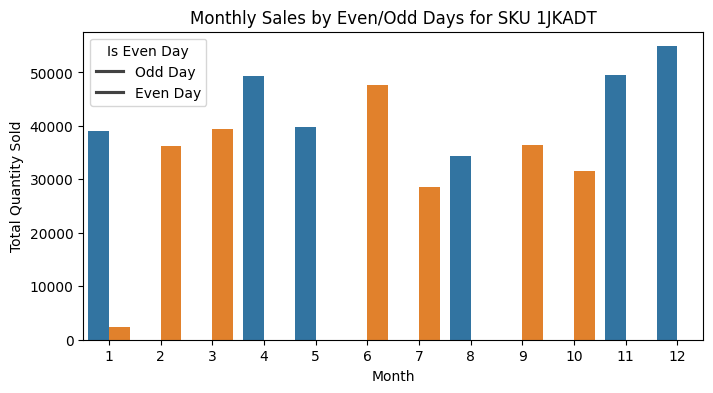

In [179]:
# data_forecast.loc[(data_forecast['sku']=='1JKADT')&(data_forecast['is_even_day']==1)&(data_forecast['qty']>0)]

data_plot = data_forecast[data_forecast['sku']=='1JKADT'].groupby(['month','is_even_day'])[['qty']].sum().reset_index()


plt.figure(figsize=(8, 4))
sns.barplot(data=data_plot, x='month', y='qty', hue='is_even_day')
plt.title('Monthly Sales by Even/Odd Days for SKU 1JKADT')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.legend(title='Is Even Day', labels=['Odd Day', 'Even Day'])
plt.show()

In [103]:
# vn_holidays = holidays.Vietnam(years=2021)
vn_holidays = holidays.US(years=2021)
print(list(vn_holidays.items())[:10])
data_forecast["is_holiday"] = (
    data_forecast["shipped_date"].dt.date.isin(vn_holidays)
).astype(int)

[(datetime.date(2021, 1, 1), "New Year's Day"), (datetime.date(2021, 12, 31), "New Year's Day (observed)"), (datetime.date(2021, 5, 31), 'Memorial Day'), (datetime.date(2021, 6, 19), 'Juneteenth National Independence Day'), (datetime.date(2021, 6, 18), 'Juneteenth National Independence Day (observed)'), (datetime.date(2021, 7, 4), 'Independence Day'), (datetime.date(2021, 7, 5), 'Independence Day (observed)'), (datetime.date(2021, 9, 6), 'Labor Day'), (datetime.date(2021, 11, 25), 'Thanksgiving Day'), (datetime.date(2021, 12, 25), 'Christmas Day')]


In [104]:
data_forecast.groupby('is_holiday').agg({'qty': 'sum', 'sku':'count', 'COGS':'sum'}).reset_index()

,is_holiday,qty,sku,COGS
0,0,3204750.0,3520,63796343.91
1,1,215904.0,150,4335046.32


Text(0.5, 1.0, 'Quantity Sold Over Time for Top 10 SKUs')

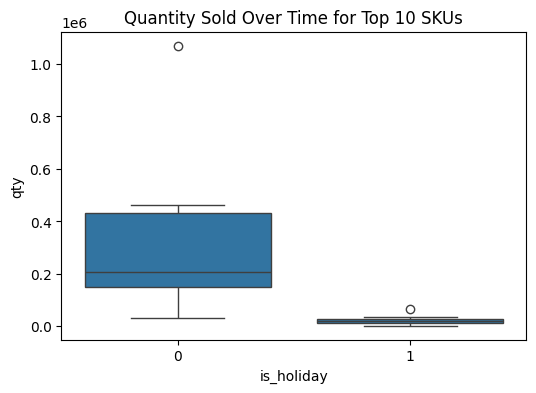

In [102]:
data_plot = data_forecast.groupby(['sku', 'is_holiday']).agg({'qty': 'sum'}).reset_index()
plt.figure(figsize=(6, 4))
sns.boxplot(data=data_plot, x='is_holiday', y='qty')
plt.title('Quantity Sold Over Time for Top 10 SKUs')

In [186]:
data_forecast.head(4)

,shipped_date,sku,qty,revenue,COGS,month,day,dayofweek,weekofyear,is_even_day
0,2021-01-01,FJDJ6B,5822.0,162934.49,89036.58,1,1,4,53,0
1,2021-01-01,VJK56C,984.0,206626.22,52348.80,1,1,4,53,0
2,2021-01-01,67LPLP,2576.0,100943.14,72128.00,1,1,4,53,0
3,2021-01-01,6HSD4J,1078.0,52806.91,33806.08,1,1,4,53,0


In [187]:
data_forecast["qty"].agg(["mean", "median", "skew", "kurt"])

mean      932.058311
median      0.000000
skew        3.102050
kurt       13.788624
Name: qty, dtype: float64

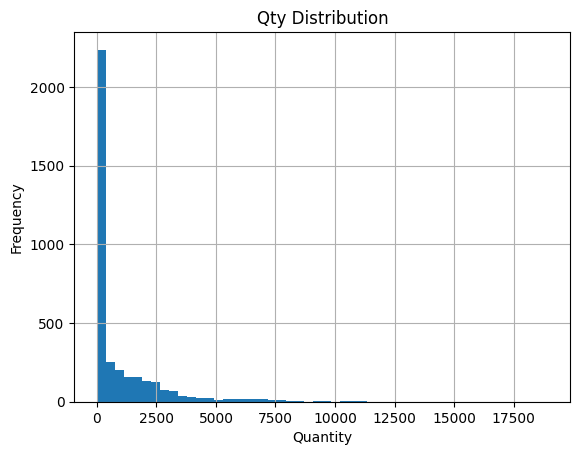

In [193]:
data_forecast["qty"].hist(bins=50)
plt.title("Qty Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

#### trend: 

Text(0, 0.5, 'Quantity Sold')

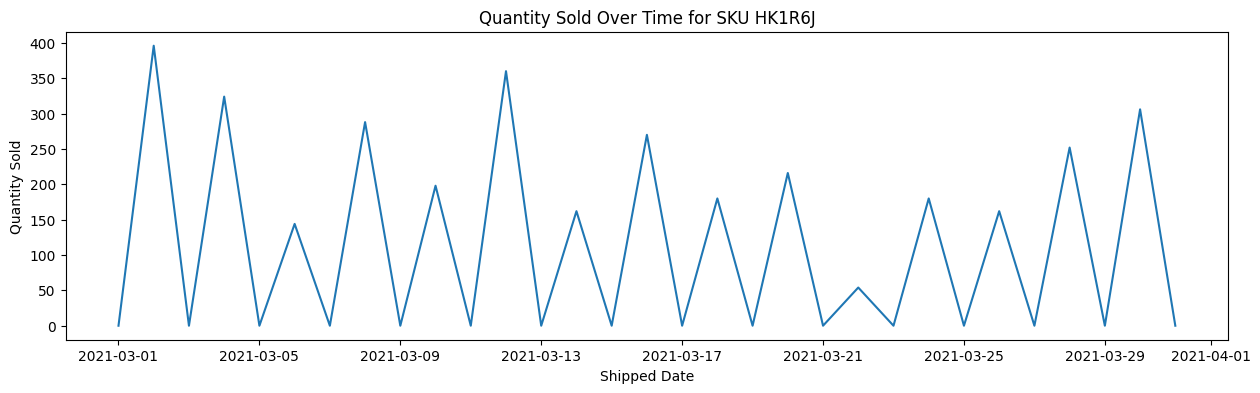

In [121]:
data_plot = data_forecast.loc[(data_forecast['sku']=='HK1R6J')&(data_forecast['month']==3)]

plt.figure(figsize=(15, 4))
sns.lineplot(data=data_plot, x='shipped_date', y='qty')
plt.title('Quantity Sold Over Time for SKU HK1R6J')
plt.xlabel('Shipped Date')
plt.ylabel('Quantity Sold')

In [182]:
data_forecast.head(4)

,shipped_date,sku,qty,revenue,COGS,month,day,dayofweek,weekofyear,is_even_day
0,2021-01-01,FJDJ6B,5822.0,162934.49,89036.58,1,1,4,53,0
1,2021-01-01,VJK56C,984.0,206626.22,52348.80,1,1,4,53,0
2,2021-01-01,67LPLP,2576.0,100943.14,72128.00,1,1,4,53,0
3,2021-01-01,6HSD4J,1078.0,52806.91,33806.08,1,1,4,53,0


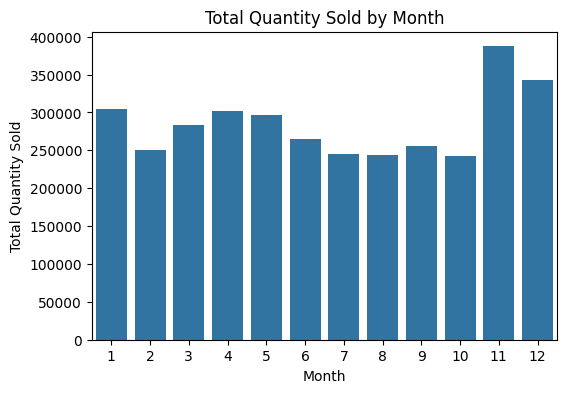

In [183]:
data_plot = data_forecast.groupby('month')['qty'].sum().reset_index()
plt.figure(figsize=(6, 4))
sns.barplot(data=data_plot, x='month', y='qty')
plt.title('Total Quantity Sold by Month')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.show()

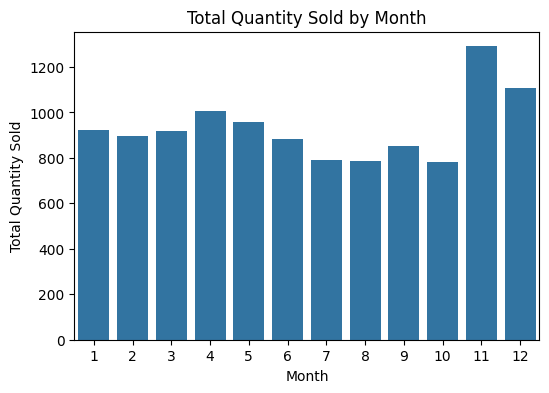

In [184]:
data_plot = data_forecast.groupby('month')['qty'].mean().reset_index()
plt.figure(figsize=(6, 4))
sns.barplot(data=data_plot, x='month', y='qty')
plt.title('Total Quantity Sold by Month')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.show()

In [194]:
data_forecast.head()

,shipped_date,sku,qty,revenue,COGS,month,day,dayofweek,weekofyear,is_even_day
0,2021-01-01,FJDJ6B,5822.0,162934.49,89036.58,1,1,4,53,0
1,2021-01-01,VJK56C,984.0,206626.22,52348.80,1,1,4,53,0
2,2021-01-01,67LPLP,2576.0,100943.14,72128.00,1,1,4,53,0
3,2021-01-01,6HSD4J,1078.0,52806.91,33806.08,1,1,4,53,0
4,2021-01-01,7XL27C,306.0,55490.65,17564.40,1,1,4,53,0


In [195]:
data_forecast.to_csv('data_processing.csv')

#### Some insights after EDA: 
- Left-skew, kurt > 0:  quantity have some spike, and can predict the log(qty) instead of qty for more consistent model 
- Sales do not affect by the holiday, campaign, .. 
- Some SKUs just have sales on even days in some specific months 